<a href="https://colab.research.google.com/github/cs-iuu/word-sense-2025-fall-ai/blob/main/notebooks/polysemy_wsi_niv_cuv_jieba_cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Measuring Polysemy Across Languages
Polysemy, the capacity of a word to have more than one senses, is fundamental to natural language. This project uses WSI (Word Sense Induction) to compare and analyze polysemy across languages, starting from English and Chinese.

Before running, you need to upload english_verses.txt and chinese_verses.txt files under bible_data folder.

A verses file contains Bible verses with their book, chapter, and verse number in CSV format like the following.
```
verse_id,text
Gen.1.1,In the beginning God created the heavens and the earth.
```


# Step 0. Install dependencies

In [1]:
!pip install torch transformers scikit-learn numpy pandas --break-system-packages

In [2]:
!pip install scipy matplotlib seaborn

In [3]:
!pip install nltk spacy jieba hdbscan

In [4]:
!python -m spacy download en_core_web_sm
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Step 2. Preprocessing: Extract Common Nouns

In [11]:
import json
import re
import pandas as pd
from pathlib import Path
from collections import Counter

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR = Path("/content") / "bible_data"
MIN_FREQ = 30          # Minimum occurrences per lemma for WSI
MAX_CONTEXT_LEN = 512  # Characters — prevents overlong inputs to transformers


# ─── Frequency Filtering ──────────────────────────────────────────────────────


def apply_frequency_filter(df: pd.DataFrame, min_freq: int = MIN_FREQ) -> tuple:
    """
    Keep only lemmas appearing at least `min_freq` times.
    Returns (filtered_df, freq_df).
    """
    freq = df.groupby("lemma").size().reset_index(name="count")
    freq = freq.sort_values("count", ascending=False)
    valid_lemmas = set(freq[freq["count"] >= min_freq]["lemma"])
    filtered = df[df["lemma"].isin(valid_lemmas)].copy()
    return filtered, freq

In [29]:
KJV_ARCHAIC_EXCLUDE_FILE = DATA_DIR / "kjv_archaic_exclude.json"
# ZH_STOPWORDS_FILE = DATA_DIR / "chinese_stopwords.json"

def _load_set_from_json(file_path: Path) -> set:
    """Loads a set of strings from a JSON file."""
    if not file_path.exists():
        print(f"WARNING: Exclusion file not found at {file_path}. Returning empty set.", flush=True)
        return set()
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise TypeError(f"Expected JSON file at {file_path} to contain a list, but got {type(data)}")
    return set(data)


# KJV-specific: exclude archaic pronouns/verbs mis-tagged as nouns
KJV_ARCHAIC_EXCLUDE = _load_set_from_json(KJV_ARCHAIC_EXCLUDE_FILE)


# ─── English Preprocessing ────────────────────────────────────────────────────


def preprocess_english(verse_csv: Path) -> pd.DataFrame:
    """
    Process English verses with spaCy.
    Returns long-format DataFrame: one row per noun occurrence.
    """
    try:
        import spacy
    except ImportError:
        raise ImportError("Run: pip install spacy --break-system-packages && python -m spacy download en_core_web_sm")

    print("  [EN] Loading spaCy model…")
    nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])

    df = pd.read_csv(verse_csv)
    print(f"  [EN] Processing {len(df):,} verses…")

    import time
    records   = []
    texts     = df["text"].tolist()
    verse_ids = df["verse_id"].tolist()
    total     = len(texts)
    t0        = time.time()

    for i, (doc, vid) in enumerate(zip(nlp.pipe(texts, batch_size=512), verse_ids), 1):
        context = doc.text[:MAX_CONTEXT_LEN]
        for token in doc:
            # Keep only common nouns; exclude proper nouns and pronouns
            if (
                token.pos_ == "NOUN"
                and not token.is_stop
                and not token.is_punct
                and len(token.lemma_) > 1
                and token.lemma_.isalpha()
                and token.lemma_.lower() not in EN_THEOLOGICAL_EXCLUDE
                ## for KJV processing-only
                and token.lemma_.lower() not in KJV_ARCHAIC_EXCLUDE
            ):
                records.append({
                    "verse_id": vid,
                    "token":    token.text,
                    "lemma":    token.lemma_.lower(),
                    "context":  context,
                })
        if i % 1000 == 0 or i == total:
            elapsed = time.time() - t0
            rate    = i / elapsed if elapsed > 0 else 0
            eta_min = (total - i) / rate / 60 if rate > 0 else 0
            print(f"    … {i:,}/{total:,} verses  "
                  f"({rate:.0f} v/s)  "
                  f"ETA {eta_min:.1f} min  "
                  f"nouns so far: {len(records):,}",
                  end="\r")

    elapsed_total = time.time() - t0
    print(f"\n  [EN] Done in {elapsed_total/60:.1f} min. "
          f"Extracted {len(records):,} noun occurrences.")
    return pd.DataFrame(records)



In [12]:
# Chinese POS tags for common nouns (jieba.posseg notation)
ZH_NOUN_PREFIXES = {"n"}           # Common noun prefix
ZH_EXCLUDE_TAGS  = {"nr", "ns", "nt", "nz", "nw", "nrt"}  # Proper nouns to exclude

# 标签  含义      标签	含义		标签	含义	  	标签	含义
# n		普通名词		f		 方位名词	 s		处所名词	 t		时间
# nr	人名			 ns		地名		 nt		机构名	   nw		作品名
# nz	其他专名		v		 普通动词	 vd		动副词		vn	 名动词
# a		形容词	   ad		副形词	 	an		名形词		d		 副词
# m		数量词	   q		量词		 r		代词			 p		介词
# c		连词			u			助词		xc		其他虚词	 w		标点符号
# PER	人名			LOC		地名		 ORG	机构名		TIME	时间

# ── Theological proper noun exclusion lists ───────────────────────────────────
# These terms are proper nouns in English (God, Lord, Christ etc.) — excluded
# by spaCy's PROPN tag — but are tagged as common nouns n by jieba in Chinese
# due to the absence of capitalisation. They must be excluded explicitly from
# the Chinese data to ensure cross-lingual comparability.
#
# English side: spaCy correctly tags God/Lord/Christ as PROPN (excluded).
# Exception: "Spirit" (Holy Spirit) is sometimes tagged NOUN by spaCy, so it
# is added to EN_THEOLOGICAL_EXCLUDE as a lemma-level backstop.
#
# Borderline cases kept in both languages:
#   先知/prophet  — generic occupational noun, polysemous, common in both
#   天使/angel    — generic supernatural being, common noun in both
#   魔鬼/devil    — common noun in EN; jieba tags n in ZH

ZH_THEOLOGICAL_EXCLUDE = {
    # Core deity names / titles
    "神",     # God (most frequent — 1244 occurrences)
    "主",     # Lord
    "上帝",   # God (formal)
    "耶和華", # Yahweh / LORD
    "基督",   # Christ
    "耶穌",   # Jesus (also usually tagged nr, but belt-and-suspenders)
    "聖靈",   # Holy Spirit
    "聖神",   # Holy Spirit (alternate form in some CUV editions)
    "彌賽亞", # Messiah
    # Adversarial proper nouns
    "撒但",   # Satan
    "別西卜", # Beelzebub
    # Exception for mis-tagged verbal phrases that Jieba assigns 'n'
    "主說",   # 'The Lord says' - incorrectly tagged as a noun by Jieba
    "亞瑪力", # Amalek or Amalekite - Proper noun, often mis-tagged as 'n'

    # ═══════════════════════════════════════════════════════════
    # Compositional patterns that jieba won't force-split
    # ═══════════════════════════════════════════════════════════

    # Subject + nominalizer 所 (compositional relative clauses)
    "神所",   # God + what (k=3, n=132: frame-splitting by verb)
    "主所",   # Lord + what (if exists)
    "人所",   # people + what (if exists)
    # Note: 聖所 "sanctuary" and 居所 "dwelling" are lexicalized - NOT excluded

    # Nominalizer 所 + verb (classical relative clauses)
    "所作",   # what is done (k=2, n=52)
    "所獻",   # what is offered (k=1, n=36)
    "所求",   # what is sought (if exists)
    "所犯",

    # Verb + object patterns
    "生子",   # give birth to son (k=1, n=32)
    "生兒",   # give birth to child (if exists)
    "定睛",   # fix eyes (verb phrase)
    "行事",   # conduct affairs

    "經上", "人陷", "對面",

    # Proper noun fragments (jieba fragments despite 100000 frequency)
    "基利",   # Fragment of 基利心山
    "大利",   # Fragment of 大利烏, 大利拉
    "米利",   # Fragment of 米利暗
    "米拉",   # Fragment of 米拉利
    "比利",   # Fragment of 比利提人, 比利人
    "示巴",   # Fragment of 拔示巴

    # Other compositional patterns
    "二人",   # two people (numeral + noun)
    "別神",   # other gods (modifier + noun)
    "木作",   # woodwork (verb-object or specialized noun)
}

EN_THEOLOGICAL_EXCLUDE = {
    # Lemma-level backstop for cases where spaCy tags as NOUN not PROPN
    "spirit",    # "Holy Spirit" — spaCy inconsistently tags as NOUN
    "ghost",     # "Holy Ghost" (KJV form; rare in NIV but present)
}

# Path to custom jieba dictionary for biblical proper names
JIEBA_DICT_PATH = DATA_DIR / "jieba_biblical_dict.txt"

# ── Post-segmentation POS correction ─────────────────────────────────────────
# jieba's POS tagger runs independently of the segmentation dictionary and
# can assign incorrect tags even for dictionary entries. These words are
# forced to tag n after segmentation regardless of what the POS tagger assigned.
#
# 地: jieba assigns uv (虛詞/copular particle) in classical subject-predicate
#     constructions like 地是空虛混沌 (Gen.1.2) because it parses 地 as a
#     topic marker rather than a subject noun. This is a known jieba limitation
#     with literary Chinese. Since English "earth" (freq=739) is always tagged
#     NOUN by spaCy, forcing 地 to n is required for cross-lingual comparability.
ZH_FORCE_NOUN_TAG = {
    "地",   # earth/ground/land — incorrectly tagged uv in copular constructions
}

# ─── Chinese Preprocessing ────────────────────────────────────────────────────


def preprocess_chinese(verse_csv: Path) -> pd.DataFrame:
    """
    Process Chinese verses with jieba (word segmentation + POS tagging).
    Returns long-format DataFrame: one row per noun occurrence.

    Three-part preprocessing strategy:
    1. Custom dictionary - fixes segmentation and marks correct POS
    2. Forced splits - breaks apart compositional phrases
    3. POS filtering - only keeps common nouns (tag 'n')
    """
    import time
    try:
        import jieba
        import jieba.posseg as pseg
    except ImportError:
        raise ImportError("Run: pip install jieba --break-system-packages")

    # Silence jieba logging FIRST
    jieba.setLogLevel("ERROR")

    # Load custom dictionary
    if JIEBA_DICT_PATH.exists():
        jieba.load_userdict(str(JIEBA_DICT_PATH))
        print(f"  [ZH] Loaded custom dictionary: {JIEBA_DICT_PATH.name}", flush=True)
    else:
        print(f"  [ZH] WARNING: custom dictionary not found at {JIEBA_DICT_PATH}", flush=True)

    # ================================================================
    # FORCE SPLITS - Compositional phrases that should be separate tokens
    # ================================================================

    # Subject + Verb patterns
    subject_verb = [
        ('人', '陷'),     # people + fall
        ('人', '行'),     # people + walk/do
        ('生', '兒'),     # give birth + child
        ('工', '都'),     # work + all
    ]

    # Modifier + Noun
    modifier_noun = [
        ('全', '會眾'),   # entire + congregation
        ('眾', '教會'),   # many + churches
    ]

    # Preposition/Locative + Noun
    locative = [
        ('在', '世'),     # at + world
        ('經', '上'),     # scripture + on
        ('床', '上'),     # bed + on
        ('對', '面'),     # opposite + face
        ('面', '向'),     # face + toward
    ]

    # Possessive constructions
    possessive_splits = [
        ('我', '心'),     # my + heart
    ]

    # Negation + Verb
    negation_verb = [
        ('不', '容'),     # not + permit
    ]

    # Combine all splits
    all_splits = (subject_verb + modifier_noun + locative
                  + possessive_splits + negation_verb)

    print(f"  [ZH] Applying {len(all_splits)} forced segmentation splits...", flush=True)
    for word_tuple in all_splits:
        jieba.suggest_freq(word_tuple, True)

    # Initialize jieba
    print("  [ZH] Building jieba model (one-time, ~10-30s)...", flush=True)
    jieba.initialize()
    print("  [ZH] Model ready.", flush=True)

    zh_stopwords = _load_chinese_stopwords()

    df = pd.read_csv(verse_csv)
    total = len(df)
    print(f"  [ZH] Processing {total:,} verses...", flush=True)
    t0 = time.time()

    records = []
    for i, row in enumerate(df.itertuples(index=False), 1):
        verse_id = row.verse_id
        text = str(row.text)
        context = text[:MAX_CONTEXT_LEN]

        for word, flag in pseg.cut(text):
            flag_str = str(flag)

            # Force known mis-tagged tokens to correct POS
            if word in ZH_FORCE_NOUN_TAG:
                flag_str = "n"

            if (
                flag_str[:1] in ZH_NOUN_PREFIXES
                and flag_str not in ZH_EXCLUDE_TAGS
                and word not in zh_stopwords
                and word not in ZH_THEOLOGICAL_EXCLUDE
                and len(word) >= 1
                and not word.isdigit()
            ):
                records.append({
                    "verse_id": verse_id,
                    "token": word,
                    "lemma": word,
                    "context": context,
                })

        # Progress reporting
        if i % 100 == 0 or i == total:
            elapsed = time.time() - t0
            rate = i / elapsed if elapsed > 0 else 0
            eta_min = (total - i) / rate / 60 if rate > 0 else 0
            print(
                f"    ... {i:,}/{total:,} verses"
                f"  ({rate:.0f} v/s)"
                f"  ETA {eta_min:.1f} min"
                f"  nouns: {len(records):,}",
                flush=True
            )

    elapsed_total = time.time() - t0
    print(f"  [ZH] Done in {elapsed_total/60:.1f} min. "
          f"Extracted {len(records):,} noun occurrences.")
    return pd.DataFrame(records)

def _load_chinese_stopwords() -> set:
    """
    Chinese function word stoplist for CUV Traditional (CHT) text.

    Design decisions:
    ─────────────────────────────────────────────────────────────
    1. CHT variants included alongside CHS equivalents for all
       characters that differ between scripts (說/说, 會/会, etc.)

    2. 人 is NOT a stopword. It is a genuine common noun meaning
       "person / people / man / humanity" and is highly polysemous
       in biblical text. Jieba tags it as n (common noun) in most
       contexts, so it passes the POS filter correctly. Removing it
       would discard one of the most semantically rich words in the
       corpus.

    3. Pronouns (他/她/祂/你/我 etc.) are NOT listed here. They are
       tagged by jieba as r (pronoun), which is already excluded by
       the POS filter (we keep only n* tags). Listing them would be
       redundant. The various gendered and honorific variants
       (他/她/它/祂) all carry the r tag and are excluded uniformly.

    4. This list covers only high-frequency grammatical function
       words that jieba may occasionally mis-tag as nouns.
       It is intentionally conservative.
    ─────────────────────────────────────────────────────────────
    """
    return {
        # Structural particles (occasionally mis-tagged as n by jieba)
        # NOTE: 地 is intentionally NOT listed here.
        # In CUV literary style, 地 is overwhelmingly used as a noun
        # (earth/land/ground) matching English "earth" (freq=739).
        # The adverbial particle use of 地 is rare in classical biblical text.
        # Removing it would create an asymmetry with English where "earth"
        # is correctly retained as a high-frequency common noun.
        "的", "得",
        # Aspect markers — CHT: 著, CHS: 着
        "了", "著", "着",
        # Conjunctions / connectives
        "和", "與", "与", "及", "或", "但", "而", "且",
        # Adverbs sometimes mis-tagged
        "也", "都", "就", "才", "又", "還", "还", "已",
        "很", "更", "最", "太", "非常",
        # Adjectives sometimes mis-tagged
        "大", "小",
        # Negation
        "不", "沒有", "没有", "未", "無", "无",
        # Existential / copular
        "是", "有", "在",
        # Determiners / quantifiers
        "一", "這", "这", "那", "各", "每", "某", "其",
        # Directional / locative words with no sense variation
        "上", "下", "中", "內", "内", "外", "前", "後", "后",
        "裡", "里", "間", "间",
        # Common verbs jieba occasionally tags as nouns in CUV
        "說", "说", "看", "去", "來", "来", "到", "給", "给",
        "要", "會", "会",

        "全",   # all, whole (determiner)
        "阿",   # prefix particle
        "為",   # to

        # Common verbs jieba occasionally tags as nouns
        "行",     # walk, do, conduct
        "作",     # do, make

        # Temporal/ordinal markers
        "先",     # first, before
        "甲",     # first (天干 ordinal)
        "亞",     # second (ordinal), also prefix in 亞洲, 亞伯拉罕 etc.
    }


In [13]:
import jieba
import jieba.posseg as pseg

jieba.load_userdict("bible_data/jieba_biblical_dict.txt")

# Test known proper nouns
test_cases = [
    "巴勒對以色列",
    "拜巴力的人",
    "神說",
    "先知說",
    "主說",
    "所作所為",
    "挪亞就這樣行．凡 神所吩咐的、他都照樣行了。"
]

for text in test_cases:
    print(f"\n{text}")
    for word, flag in pseg.cut(text):
        print(f"  {word}/{flag}")
# ```

# **Expected:**
# ```
# 巴勒對以色列
#   巴勒/nr   ← Should be nr (proper noun)

# 拜巴力的人
#   拜/v
#   巴力/nr   ← Should be nr (proper noun)
# ```

# **If you're getting:**
# ```
#   巴勒/n    ← WRONG
#   巴力/n    ← WRONG


巴勒對以色列
  巴勒/nr
  對/x
  以色列/ns

拜巴力的人
  拜/v
  巴力/nr
  的/uj
  人/n

神說
  神/n
  說/v

先知說
  先知/n
  說/zg

主說
  主說/v

所作所為
  所作/n
  所為/c

挪亞就這樣行．凡 神所吩咐的、他都照樣行了。
  挪亞/ns
  就/d
  這樣/r
  行/n
  ．/x
  凡/d
   /x
  神所/n
  吩咐/v
  的/uj
  、/x
  他/r
  都/d
  照樣行/v
  了/ul
  。/x


In [15]:
import pandas as pd

df_zh = pd.read_csv("bible_data/chinese_wsi_results.csv")

# Load your dictionary
with open("bible_data/jieba_biblical_dict.txt", 'r', encoding='utf-8') as f:
    dict_proper_nouns = set()
    for line in f:
        if line.strip() and not line.startswith('#'):
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] in ['nr', 'ns']:
                dict_proper_nouns.add(parts[0])

# Check which dictionary proper nouns appear in your results
leaked_proper_nouns = df_zh[df_zh['lemma'].isin(dict_proper_nouns)]

print("Proper nouns from dictionary that leaked into results:")
print(leaked_proper_nouns[['lemma', 'n_instances', 'k_hdbscan']].sort_values('n_instances', ascending=False))

Proper nouns from dictionary that leaked into results:
Empty DataFrame
Columns: [lemma, n_instances, k_hdbscan]
Index: []


In [ ]:
print("=" * 60)
print("Step 2: Preprocessing")
print("=" * 60)

# ── English ───────────────────────────────────────────────────
en_raw = preprocess_english(DATA_DIR / "english_verses.csv")
en_filtered, en_freq = apply_frequency_filter(en_raw)
en_filtered.to_csv(DATA_DIR / "english_nouns.csv", index=False, encoding="utf-8")
en_freq.to_csv(DATA_DIR / "english_noun_freq.csv", index=False, encoding="utf-8")
print(f"  [EN] {en_filtered['lemma'].nunique():,} lemmas ≥ {MIN_FREQ} occurrences retained.")

# ── Summary ───────────────────────────────────────────────────
print("\n── Preprocessing Summary ──")
print(f"  EN noun tokens (filtered) : {len(en_filtered):,}")
print(f"  EN unique lemmas          : {en_filtered['lemma'].nunique():,}")

print("\n  Top 10 English nouns:")
print(en_freq.head(10).to_string(index=False))

print("\n✓ Step 2 complete.\n")

In [14]:
print("=" * 60)
print("Step 2: Preprocessing")
print("=" * 60)

# ── Chinese ───────────────────────────────────────────────────
zh_raw = preprocess_chinese(DATA_DIR / "chinese_verses.csv")
zh_filtered, zh_freq = apply_frequency_filter(zh_raw)
zh_filtered.to_csv(DATA_DIR / "chinese_nouns.csv", index=False, encoding="utf-8")
zh_freq.to_csv(DATA_DIR / "chinese_noun_freq.csv", index=False, encoding="utf-8")
print(f"  [ZH] {zh_filtered['lemma'].nunique():,} lemmas ≥ {MIN_FREQ} occurrences retained.")

# ── Summary ───────────────────────────────────────────────────
print("\n── Preprocessing Summary ──")
print(f"  ZH noun tokens (filtered) : {len(zh_filtered):,}")
print(f"  ZH unique lemmas          : {zh_filtered['lemma'].nunique():,}")

print("\n  Top 10 Chinese nouns:")
print(zh_freq.head(10).to_string(index=False))

print("\n✓ Step 2 complete.\n")

Step 2: Preprocessing
  [ZH] Loaded custom dictionary: jieba_biblical_dict.txt
  [ZH] Applying 13 forced segmentation splits...
  [ZH] Building jieba model (one-time, ~10-30s)...
  [ZH] Model ready.
  [ZH] Processing 31,027 verses...
    ... 100/31,027 verses  (35 v/s)  ETA 14.9 min  nouns: 343
    ... 200/31,027 verses  (34 v/s)  ETA 15.3 min  nouns: 603
    ... 300/31,027 verses  (35 v/s)  ETA 14.5 min  nouns: 852
    ... 400/31,027 verses  (34 v/s)  ETA 14.9 min  nouns: 1,091
    ... 500/31,027 verses  (33 v/s)  ETA 15.6 min  nouns: 1,366
    ... 600/31,027 verses  (33 v/s)  ETA 15.6 min  nouns: 1,639
    ... 700/31,027 verses  (32 v/s)  ETA 15.7 min  nouns: 1,972
    ... 800/31,027 verses  (33 v/s)  ETA 15.3 min  nouns: 2,246
    ... 900/31,027 verses  (34 v/s)  ETA 14.8 min  nouns: 2,516
    ... 1,000/31,027 verses  (34 v/s)  ETA 14.6 min  nouns: 2,797
    ... 1,100/31,027 verses  (34 v/s)  ETA 14.8 min  nouns: 3,085
    ... 1,200/31,027 verses  (34 v/s)  ETA 14.7 min  nouns: 3,37

# Step 3: Extract Context Embeddings

In [15]:
import os
import numpy as np
import pandas as pd
import torch
import time # Import time module for progress tracking
from pathlib import Path
from transformers import AutoTokenizer, AutoModel
from typing import List, Tuple

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR    = Path("/content") / "bible_data"
MODEL_NAME  = "xlm-roberta-base"   # Multilingual; same model for EN and ZH
BATCH_SIZE  = 32                   # Reduce to 8-16 if OOM on CPU
LAYERS      = [-1, -2, -3, -4]     # Last 4 layers averaged (standard WSI practice)
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SEQ_LEN = 128                  # Max subword tokens per sentence

print(f"Using device: {DEVICE}")

# ─── Model Loading ────────────────────────────────────────────────────────────

def load_model():
    print(f"  [model] Loading {MODEL_NAME}…")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model     = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


# ─── Embedding Extraction ─────────────────────────────────────────────────────

def get_target_embedding(
    tokenizer,
    model,
    sentences:  List[str],
    target_words: List[str],
) -> np.ndarray:
    """
    For each (sentence, target_word) pair, extract the contextual embedding
    of the target by:
      1. Tokenizing the sentence
      2. Finding subword token positions for the target word
      3. Averaging hidden states across the last 4 layers at those positions
      4. Mean-pooling across subwords for multi-token targets

    Returns: np.ndarray of shape (N, hidden_dim)
    """
    print(f"  Starting embedding extraction for {len(sentences):,} sentences...", flush=True)
    all_embeddings = []
    total_sentences = len(sentences)
    t0 = time.time()

    for i in range(0, total_sentences, BATCH_SIZE):
        batch_sents  = sentences[i : i + BATCH_SIZE]
        batch_targets = target_words[i : i + BATCH_SIZE]

        encoded = tokenizer(
            batch_sents,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_offsets_mapping=True,
        )
        offset_mappings = encoded.pop("offset_mapping")  # not passed to model

        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)

        # Stack selected hidden layers: shape (n_layers, batch, seq_len, hidden)
        hidden_states = torch.stack(
            [outputs.hidden_states[l] for l in LAYERS], dim=0
        )
        # Mean over selected layers: (batch, seq_len, hidden)
        layer_mean = hidden_states.mean(dim=0).cpu().numpy()

        input_ids = encoded["input_ids"].cpu().numpy()

        for j, (target, offsets_j) in enumerate(zip(batch_targets, offset_mappings)):
            # Re-encode the target word alone to find its subword tokens
            target_enc = tokenizer.encode(
                target, add_special_tokens=False
            )
            # Find target subword positions in the sentence encoding
            target_positions = _find_subword_positions(
                input_ids[j].tolist(), target_enc
            )
            if target_positions:
                token_emb = layer_mean[j][target_positions].mean(axis=0)
            else:
                # Fallback: mean-pool entire sequence (excluding [CLS]/[SEP])
                seq_len = (input_ids[j] != tokenizer.pad_token_id).sum()
                token_emb = layer_mean[j][1 : seq_len - 1].mean(axis=0)

            all_embeddings.append(token_emb)

        # Progress indicator (print every 1000 sentences or at the end)
        current_processed = i + len(batch_sents)
        if current_processed % 1000 == 0 or current_processed == total_sentences:
            elapsed_time = time.time() - t0
            rate = current_processed / elapsed_time if elapsed_time > 0 else 0
            eta_seconds = (total_sentences - current_processed) / rate if rate > 0 else 0
            eta_minutes = eta_seconds / 60
            print(f"    ... {current_processed:,}/{total_sentences:,} sentences "
                  f"({rate:.0f} s/s) "
                  f"ETA {eta_minutes:.1f} min ", flush=True)

    print(f"  Finished embedding extraction. Total {len(all_embeddings):,} embeddings.", flush=True)
    embeddings = np.array(all_embeddings, dtype=np.float32)
    # L2 normalize for cosine-based clustering
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    return embeddings / norms


def _find_subword_positions(
    sentence_ids: List[int], target_ids: List[int]
) -> List[int]:
    """Find the start position of `target_ids` as a subsequence in `sentence_ids`."""
    n, m = len(sentence_ids), len(target_ids)
    for start in range(n - m + 1):
        if sentence_ids[start : start + m] == target_ids:
            return list(range(start, start + m))
    return []


# ─── Per-language Pipeline ────────────────────────────────────────────────────

def extract_embeddings_for_language(
    lang: str,
    noun_csv: Path,
    tokenizer,
    model,
) -> None:
    """Load nouns, extract embeddings, and save as .npz."""
    out_path = DATA_DIR / f"{lang}_embeddings.npz"
    if out_path.exists():
        print(f"  [{lang.upper()}] Embeddings already exist — skipping.")
        return

    df = pd.read_csv(noun_csv)
    print(f"  [{lang.upper()}] Extracting embeddings for {len(df):,} noun occurrences…")

    embeddings = get_target_embedding(
        tokenizer,
        model,
        sentences    = df["context"].tolist(),
        target_words = df["token"].tolist(),
    )
    print()  # newline after progress indicator

    np.savez_compressed(
        out_path,
        embeddings = embeddings,
        lemmas     = df["lemma"].to_numpy(dtype=str),
        verse_ids  = df["verse_id"].to_numpy(dtype=str),
        tokens     = df["token"].to_numpy(dtype=str),
    )
    print(f"  [{lang.upper()}] Saved {embeddings.shape} embeddings → {out_path.name}")

Using device: cpu


In [ ]:
print("=" * 60)
print("Step 3: Contextual Embedding Extraction (XLM-R)")
print("=" * 60)

tokenizer, model = load_model()

extract_embeddings_for_language(
    "english",
    DATA_DIR / "english_nouns.csv",
    tokenizer, model,
)

print("\n✓ Step 3 complete.\n")


In [16]:
print("=" * 60)
print("Step 3: Contextual Embedding Extraction (XLM-R)")
print("=" * 60)

tokenizer, model = load_model()

extract_embeddings_for_language(
    "chinese",
    DATA_DIR / "chinese_nouns.csv",
    tokenizer, model,
)

print("\n✓ Step 3 complete.\n")


Step 3: Contextual Embedding Extraction (XLM-R)
  [model] Loading xlm-roberta-base…


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [CHINESE] Extracting embeddings for 68,928 noun occurrences…
  Starting embedding extraction for 68,928 sentences...
    ... 4,000/68,928 sentences (5 s/s) ETA 203.9 min 
    ... 8,000/68,928 sentences (6 s/s) ETA 181.6 min 
    ... 12,000/68,928 sentences (6 s/s) ETA 168.4 min 
    ... 16,000/68,928 sentences (5 s/s) ETA 162.8 min 
    ... 20,000/68,928 sentences (5 s/s) ETA 153.1 min 
    ... 24,000/68,928 sentences (5 s/s) ETA 142.0 min 
    ... 28,000/68,928 sentences (5 s/s) ETA 131.0 min 
    ... 32,000/68,928 sentences (5 s/s) ETA 119.2 min 
    ... 36,000/68,928 sentences (5 s/s) ETA 102.0 min 
    ... 40,000/68,928 sentences (6 s/s) ETA 87.2 min 
    ... 44,000/68,928 sentences (5 s/s) ETA 75.7 min 
    ... 48,000/68,928 sentences (5 s/s) ETA 64.0 min 
    ... 52,000/68,928 sentences (5 s/s) ETA 52.1 min 
    ... 56,000/68,928 sentences (5 s/s) ETA 39.8 min 
    ... 60,000/68,928 sentences (5 s/s) ETA 27.3 min 
    ... 64,000/68,928 sentences (5 s/s) ETA 15.0 min 
    ... 68

# Step 4: WSI Clustering

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from typing import Tuple, Dict
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR      = Path("/content") / "bible_data"
RANDOM_STATE  = 42
# NEW: Make second_cluster_threshold configurable
SECOND_CLUSTER_THRESHOLD = 0.08 # If the second largest cluster is below this proportion, count as monosemous

# ─── HDBSCAN ──────────────────────────────────────────────

import hdbscan
from sklearn.decomposition import PCA

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > 200:
        n_components = min(100, n_samples - 1, n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    # too conservative
    # min_cluster_size = max(8, int(0.05 * n_samples))
    # NEW: More liberal parameters
    min_cluster_size = max(6, int(0.03 * n_samples))  # 3% instead of 5%

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    # Use the configurable variable
    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:  # ← Changed this line
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels


# ─── Run WSI for entire language ──────────────────────────────────────────────

def run_wsi_for_language(lang: str):
    """
    L Load embeddings and run WSI for all lemmas in a language.
    Saves two files:
      1. {lang}_wsi_results.csv    - summary stats per lemma
      2. {lang}_sense_labels.csv   - cluster assignments per occurrence
    """
    embeddings_file = DATA_DIR / f"{lang}_embeddings.npz"
    nouns_file      = DATA_DIR / f"{lang}_nouns.csv"

    if not embeddings_file.exists():
        print(f"  [{lang.upper()}] ERROR: {embeddings_file.name} not found. Run Step 3 first.")
        return

    print(f"\n  [{lang.upper()}] Loading embeddings…")
    data = np.load(embeddings_file, allow_pickle=True)
    lemmas_array = data["lemmas"]
    embeddings   = data["embeddings"]
    verse_ids    = data["verse_ids"]
    unique_lemmas = np.unique(lemmas_array)

    print(f"  [{lang.upper()}] Running WSI for {len(unique_lemmas):,} lemmas…")

    results = []
    all_labels = []  # Collect per-instance labels for sense_labels.csv

    for i, lemma in enumerate(unique_lemmas):
        mask = (lemmas_array == lemma)
        lemma_embeds = embeddings[mask]
        lemma_vids   = verse_ids[mask]

        k_hdb, labels_hdb = induce_senses_hdbscan(lemma_embeds)

        results.append({
            "lemma": lemma,
            "n_instances": len(lemma_embeds),
            "k_hdbscan": k_hdb,
        })

        for vid, cluster in zip(lemma_vids, labels_hdb):
            all_labels.append({
                "lemma": lemma,
                "verse_id": vid,
                "cluster_hdbscan": int(cluster),
            })

        if (i + 1) % 50 == 0 or (i + 1) == len(unique_lemmas):
            print(f"    … {i + 1:,}/{len(unique_lemmas):,} lemmas", end="\r")


    # Save summary results
    df = pd.DataFrame(results)
    out_path = DATA_DIR / f"{lang}_wsi_results.csv"
    df.to_csv(out_path, index=False)
    print(f"\n  [{lang.upper()}] Saved: {out_path.name}")

    # Save per-instance cluster labels
    labels_df = pd.DataFrame(all_labels)
    labels_path = DATA_DIR / f"{lang}_sense_labels.csv"
    labels_df.to_csv(labels_path, index=False)
    print(f"  [{lang.upper()}] Saved: {labels_path.name}")

    print(f"  [{lang.upper()}] Mean k (HDBSCAN): {df['k_hdbscan'].mean():.2f}  "
      f"Median: {df['k_hdbscan'].median():.0f}  "
      f"Monosemous (k=1): {(df['k_hdbscan']==1).sum()} / {len(df)}")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
print("=" * 60)
print("Step 4: Word Sense Induction (WSI)")
print("=" * 60)

run_wsi_for_language("english")

# Quick comparison preview
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")

print("\n── Quick Comparison Preview ──")
print(f"  EN | mean senses/lemma : {en['k_hdbscan'].mean():.3f}")
print(f"  EN | % polysemous lemmas       : {(en['k_hdbscan'] > 1).mean()*100:.1f}%")

print("\n✓ Step 4 complete.\n")

In [18]:
print("=" * 60)
print("Step 4: Word Sense Induction (WSI)")
print("=" * 60)

run_wsi_for_language("chinese")

# Quick comparison preview
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

print("\n── Quick Comparison Preview ──")
print(f"  ZH | mean senses/lemma : {zh['k_hdbscan'].mean():.3f}")
print(f"  ZH | % polysemous lemmas       : {(zh['k_hdbscan'] > 1).mean()*100:.1f}%")

print("\n✓ Step 4 complete.\n")

Step 4: Word Sense Induction (WSI)

  [CHINESE] Loading embeddings…
  [CHINESE] Running WSI for 496 lemmas…
    … 496/496 lemmas
  [CHINESE] Saved: chinese_wsi_results.csv
  [CHINESE] Saved: chinese_sense_labels.csv
  [CHINESE] Mean k (HDBSCAN): 1.23  Median: 1  Monosemous (k=1): 400 / 496

── Quick Comparison Preview ──
  ZH | mean senses/lemma : 1.232
  ZH | % polysemous lemmas       : 19.4%

✓ Step 4 complete.



# Step 5: Validation and Statistical Analysis

In [19]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from typing import Optional, Tuple

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR    = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family":  "DejaVu Sans",
    "font.size":    11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})


# ─── WordNet Validation (English) ────────────────────────────────────────────

def get_wordnet_sense_counts(lemmas: list) -> dict:
    """
    Look up the number of synsets for each lemma in Princeton WordNet.
    Noun synsets only (pos='n').
    """
    try:
        from nltk.corpus import wordnet as wn
    except ImportError:
        raise ImportError("Run: pip install nltk --break-system-packages && "
                          "python -c \"import nltk; nltk.download('wordnet')\"")

    counts = {}
    for lemma in lemmas:
        synsets = wn.synsets(lemma.lower(), pos=wn.NOUN)
        counts[lemma] = len(synsets)
    return counts


def validate_english(en_results: pd.DataFrame) -> pd.DataFrame:
    """
    Correlate WSI-induced k_ward with WordNet sense counts for English nouns.
    Returns a merged DataFrame with both counts.
    """
    print("  [validate] Looking up Princeton WordNet sense counts…")
    lemmas = en_results["lemma"].tolist()
    wn_counts = get_wordnet_sense_counts(lemmas)

    en_results = en_results.copy()
    en_results["wn_senses"] = en_results["lemma"].map(wn_counts).fillna(0).astype(int)

    # Keep only lemmas with at least 1 WordNet entry
    valid = en_results[en_results["wn_senses"] > 0].copy()

    rho, p = stats.spearmanr(valid["k_hdbscan"], valid["wn_senses"])
    print(f"  [validate] EN Spearman ρ(k_hdbscan, WN_senses) = {rho:.3f}  p = {p:.4f}  "
          f"(n={len(valid)})")

    return valid, rho, p


# ─── WordNet Validation (Chinese) ────────────────────────────────────────────

def get_chinese_wordnet_sense_counts(lemmas: list) -> dict:
    """
    Look up the number of synsets for each lemma in Chinese WordNet (cmn).
    Noun synsets only (pos='n').
    """
    try:
        from nltk.corpus import wordnet as wn
    except ImportError:
        raise ImportError("Run: pip install nltk --break-system-packages && "
                          "python -c \"import nltk; nltk.download('wordnet')\"")

    counts = {}
    for lemma in lemmas:
        # 'cmn' is the language code for Mandarin Chinese in WordNet
        # Note: Chinese WordNet coverage in NLTK might be limited compared to English
        synsets = wn.synsets(lemma, lang="cmn", pos=wn.NOUN)
        counts[lemma] = len(synsets)
    return counts


def validate_chinese(zh_results: pd.DataFrame) -> pd.DataFrame:
    """
    Correlate WSI-induced k_ward with Chinese WordNet sense counts for Chinese nouns.
    Returns a merged DataFrame with both counts.
    """
    print("  [validate] Looking up Chinese WordNet sense counts…")
    lemmas = zh_results["lemma"].tolist()
    cwn_counts = get_chinese_wordnet_sense_counts(lemmas)

    zh_results = zh_results.copy()
    zh_results["cwn_senses"] = zh_results["lemma"].map(cwn_counts).fillna(0).astype(int)

    # Keep only lemmas with at least 1 WordNet entry
    valid = zh_results[zh_results["cwn_senses"] > 0].copy()

    if len(valid) == 0:
        print("  [validate] No Chinese lemmas found in NLTK's Chinese WordNet. Skipping Spearman correlation.")
        rho, p = np.nan, np.nan # No correlation if no data
    elif len(valid) == 1:
        print("  [validate] Only one Chinese lemma found in NLTK's Chinese WordNet. Skipping Spearman correlation.")
        rho, p = np.nan, np.nan # Spearman requires at least two data points
    else:
        rho, p = stats.spearmanr(valid["k_hdbscan"], valid["cwn_senses"])
        print(f"  [validate] ZH Spearman ρ(k_hdbscan, CWN_senses) = {rho:.3f}  p = {p:.4f}  "
              f"(n={len(valid)})")

    return valid, rho, p


# ─── Statistical Comparison ──────────────────────────────────────────────────

def mann_whitney_comparison(
    en_k: np.ndarray,
    zh_k: np.ndarray,
) -> dict:
    """
    Mann-Whitney U test comparing mean sense counts between EN and ZH.
    Also computes Cohen's d and the common language effect size (CLES).
    """
    u_stat, p_val = stats.mannwhitneyu(en_k, zh_k, alternative="two-sided")
    n1, n2        = len(en_k), len(zh_k)
    cles          = u_stat / (n1 * n2)  # Common Language Effect Size

    # Cohen's d (for reference alongside CLES)
    pooled_std = np.sqrt(
        ((n1 - 1) * en_k.std(ddof=1) ** 2 + (n2 - 1) * zh_k.std(ddof=1) ** 2)
        / (n1 + n2 - 2)
    )
    cohens_d = (en_k.mean() - zh_k.mean()) / (pooled_std + 1e-9)

    return {
        "en_mean_k":   round(en_k.mean(), 4),
        "zh_mean_k":   round(zh_k.mean(), 4),
        "en_median_k": round(float(np.median(en_k)), 4),
        "zh_median_k": round(float(np.median(zh_k)), 4),
        "en_std_k":    round(en_k.std(ddof=1), 4),
        "zh_std_k":    round(zh_k.std(ddof=1), 4),
        "U_statistic": round(u_stat, 2),
        "p_value":     round(p_val, 6),
        "CLES":        round(cles, 4),
        "cohens_d":    round(cohens_d, 4),
        "n_en":        int(n1),
        "n_zh":        int(n2),
    }


# ─── Figures ─────────────────────────────────────────────────────────────────

def plot_sense_distribution(df: pd.DataFrame, lang: str, col: str = "k_hdbscan") -> None:
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#4C72B0", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Number of Induced Senses (k)")
    ax.set_ylabel("Number of Lemmas")
    ax.set_title(f"{lang.capitalize()} — Distribution of Induced Senses per Noun Lemma")
    ax.set_xticks(range(1, df[col].max() + 1))
    fig.tight_layout()
    path = FIG_DIR / f"sense_distribution_{lang}.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")


def plot_comparison_boxplot(en_df: pd.DataFrame, zh_df: pd.DataFrame) -> None:
    combined = pd.concat([
        en_df[["k_hdbscan"]].assign(Language="English"),
        zh_df[["k_hdbscan"]].assign(Language="Chinese"),
    ])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=combined, x="Language", y="k_hdbscan",
                   palette=["#4C72B0", "#DD8452"], inner="box",
                   cut=0,   # ← add this to fix sns artifact of extending beyond 8
                   ax=ax)
    ax.set_ylabel("Induced Senses per Lemma (k, Ward)")
    ax.set_title("Distribution of Polysemy Degree: English vs. Chinese Common Nouns\n"
                 "(Bible Parallel Corpus, WSI via XLM-R + Agglomerative Clustering)")
    fig.tight_layout()
    path = FIG_DIR / "comparison_violinplot.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")


def plot_wordnet_correlation(valid_df: pd.DataFrame, rho: float, p: float) -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(valid_df["wn_senses"], valid_df["k_hdbscan"],
               alpha=0.4, s=20, color="#4C72B0")
    ax.set_xlabel("WordNet Noun Synset Count")
    ax.set_ylabel("WSI-Induced k (Ward)")
    ax.set_title(f"Validation: WSI k vs. WordNet Senses (English Nouns)\n"
                 f"Spearman ρ = {rho:.3f}, p = {p:.4f}")
    # Trend line
    m, b = np.polyfit(valid_df["wn_senses"], valid_df["k_hdbscan"], 1)
    x_line = np.linspace(valid_df["wn_senses"].min(), valid_df["wn_senses"].max(), 100)
    ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, linestyle="--")
    fig.tight_layout()
    path = FIG_DIR / "wordnet_correlation_en.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")

def plot_wordnet_correlation_chinese(valid_df: pd.DataFrame, rho: float, p: float) -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(valid_df["cwn_senses"], valid_df["k_hdbscan"],
               alpha=0.4, s=20, color="#DD8452") # Using a different color for Chinese
    ax.set_xlabel("Chinese WordNet Noun Synset Count")
    ax.set_ylabel("WSI-Induced k (Ward)")
    ax.set_title(f"Validation: WSI k vs. Chinese WordNet Senses\n"
                 f"Spearman ρ = {rho:.3f}, p = {p:.4f}")
    # Trend line
    # Only plot trend line if there's enough data and correlation is valid
    if not np.isnan(rho) and len(valid_df) > 1:
        m, b = np.polyfit(valid_df["cwn_senses"], valid_df["k_hdbscan"], 1)
        x_line = np.linspace(valid_df["cwn_senses"].min(), valid_df["cwn_senses"].max(), 100)
        ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, linestyle="--")

    fig.tight_layout()
    path = FIG_DIR / "wordnet_correlation_zh.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")


In [20]:
print("=" * 60)
print("Step 5: Validation and Statistical Analysis")
print("=" * 60)

en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# ── Validation (English vs. WordNet) ──────────────────────────
valid_en, rho_en, p_en = validate_english(en)
valid_en.to_csv(OUTPUT_DIR / "validation_correlation_en.csv", index=False)

# ── Validation (Chinese vs. WordNet) ──────────────────────────
valid_zh, rho_zh, p_zh = validate_chinese(zh)
valid_zh.to_csv(OUTPUT_DIR / "validation_correlation_zh.csv", index=False)

# ── Statistical Comparison ────────────────────────────────────
stats_result = mann_whitney_comparison(
    en["k_hdbscan"].values,
    zh["k_hdbscan"].values,
)
stats_df = pd.DataFrame([stats_result])
stats_df.to_csv(OUTPUT_DIR / "statistical_comparison.csv", index=False)

print("\n── Statistical Comparison Results ──")
for k, v in stats_result.items():
    print(f"  {k:22s}: {v}")

# ── Figures ───────────────────────────────────────────────────
plot_sense_distribution(en, "english")
plot_sense_distribution(zh, "chinese")
plot_comparison_boxplot(en, zh)
plot_wordnet_correlation(valid_en, rho_en, p_en)
# You might want to create a plot for Chinese WordNet correlation as well, if coverage is good
# plot_wordnet_correlation_chinese(valid_zh, rho_zh, p_zh) # This would require a new function
# plot_silhouette_distribution(en, zh)

# ── Interpretation ────────────────────────────────────────────
print("\n── Interpretation ──")
if stats_result["p_value"] < 0.05:
    direction = "English" if stats_result["en_mean_k"] > stats_result["zh_mean_k"] else "Chinese"
    print(f"  Significant difference found (p={stats_result['p_value']:.4f}).")
    print(f"  {direction} nouns show higher mean polysemy degree.")
else:
    print(f"  No significant difference found (p={stats_result['p_value']:.4f}).")

d = abs(stats_result["cohens_d"])
magnitude = "small" if d < 0.2 else ("medium" if d < 0.5 else "large")
print(f"  Effect size: Cohen's d = {stats_result['cohens_d']:.3f} ({magnitude})")
print(f"  Spearman ρ (EN WSI vs. WordNet): {rho_en:.3f} (p={p_en:.4f})")
print(f"  Spearman ρ (ZH WSI vs. WordNet): {rho_zh:.3f} (p={p_zh:.4f})")

print("\n✓ Step 5 complete.\n")

Step 5: Validation and Statistical Analysis
  [validate] Looking up Princeton WordNet sense counts…
  [validate] EN Spearman ρ(k_hdbscan, WN_senses) = 0.147  p = 0.0002  (n=630)
  [validate] Looking up Chinese WordNet sense counts…


/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 14869976-n in '14869976-n	cmn:lemma	污点
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 14869977-n in '14869977-n	cmn:lemma	小斑
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15168570-n in '15168570-n	cmn:lemma	规定的睡觉时间
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15171146-n in '15171146-n	cmn:lemma	节日
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15171147-n in '15171147-n	cmn:lemma	纪念日
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15171739-n in '15171739-n	cmn:lemma	竞技状态不佳的日子
'
  

  [validate] ZH Spearman ρ(k_hdbscan, CWN_senses) = 0.072  p = 0.4091  (n=134)

── Statistical Comparison Results ──
  en_mean_k             : 1.5692
  zh_mean_k             : 1.2319
  en_median_k           : 1.0
  zh_median_k           : 1.0
  en_std_k              : 0.7054
  zh_std_k              : 0.5437
  U_statistic           : 201983.0
  p_value               : 0.0
  CLES                  : 0.6403
  cohens_d              : 0.5274
  n_en                  : 636
  n_zh                  : 496
  [fig] Saved: sense_distribution_english.png
  [fig] Saved: sense_distribution_chinese.png
  [fig] Saved: comparison_violinplot.png
  [fig] Saved: wordnet_correlation_en.png

── Interpretation ──
  Significant difference found (p=0.0000).
  English nouns show higher mean polysemy degree.
  Effect size: Cohen's d = 0.527 (large)
  Spearman ρ (EN WSI vs. WordNet): 0.147 (p=0.0002)
  Spearman ρ (ZH WSI vs. WordNet): 0.072 (p=0.4091)

✓ Step 5 complete.



## 5.1 WordNet Coverage

In [21]:
import nltk
from nltk.corpus import wordnet as wn
import pandas as pd
from pathlib import Path

# Ensure the 'en' DataFrame is loaded, if not already in memory
# (assuming DATA_DIR is defined from previous cells)
if 'en' not in locals():
    DATA_DIR = Path("/content") / "bible_data"
    en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")

english_lemmas = en['lemma'].tolist()
n_with_synsets_en = sum(1 for lemma in english_lemmas
                          if len(wn.synsets(lemma.lower(), pos=wn.NOUN)) > 0)

total_lemmas_en = len(english_lemmas)
print(f"English WordNet Coverage: {n_with_synsets_en}/{total_lemmas_en} = {n_with_synsets_en/total_lemmas_en:.1%}")


English WordNet Coverage: 630/636 = 99.1%


In [22]:
import nltk
from nltk.corpus import wordnet as wn
import pandas as pd

# Ensure the 'zh' DataFrame is loaded, if not already in memory
# (assuming DATA_DIR is defined from previous cells)
if 'zh' not in locals():
    DATA_DIR = Path("/content") / "bible_data"
    zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

chinese_lemmas = zh['lemma'].tolist()
n_with_synsets = sum(1 for lemma in chinese_lemmas
                     if len(wn.synsets(lemma, lang="cmn")) > 0)

total_lemmas = len(chinese_lemmas)
print(f"Chinese WordNet Coverage: {n_with_synsets}/{total_lemmas} = {n_with_synsets/total_lemmas:.1%}")

Chinese WordNet Coverage: 142/496 = 28.6%


# Step 6: Qualitative Analysis

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# ─── Configuration ────────────────────────────────────────────────────────────

# DATA_DIR and OUTPUT_DIR are defined in previous cells and are globally accessible.

TOP_N_WORDS       = 20   # Top N most polysemous lemmas per language
EXAMPLES_PER_SENSE = 2   # Number of example verses per cluster

# ─── Sense Example Retrieval (Corrected) ─────────────────────────────────────────────────

def get_sense_examples(
    lang: str,
    top_n: int = TOP_N_WORDS,
    examples_per_sense: int = EXAMPLES_PER_SENSE,
) -> str:
    """
    For the top_n most polysemous lemmas, retrieve example contexts
    for each induced sense cluster.

    Returns a formatted string ready for a paper's qualitative appendix.
    """
    results_df = pd.read_csv(DATA_DIR / f"{lang}_wsi_results.csv")
    labels_df  = pd.read_csv(DATA_DIR / f"{lang}_sense_labels.csv")
    nouns_df   = pd.read_csv(DATA_DIR / f"{lang}_nouns.csv")

    # Top polysemous by k_hdbscan (was k_ward)
    poly = results_df[results_df["k_hdbscan"] > 1].nlargest(top_n, "k_hdbscan")

    # Merge labels with original contexts
    merged = labels_df.merge(
        nouns_df[["lemma", "verse_id", "context"]].drop_duplicates(),
        on=["lemma", "verse_id"],
        how="left",
    )

    lines = []
    lines.append(f"{'='*60}")
    lines.append(f"QUALITATIVE SENSE ANALYSIS — {lang.upper()}")
    # Updated title to reflect HDBSCAN
    lines.append(f"Top {top_n} Most Polysemous Nouns (WSI, HDBSCAN Clustering)")
    lines.append(f"{'='*60}\n")

    for _, row in poly.iterrows():
        lemma = row["lemma"]
        # Use k_hdbscan
        k     = int(row["k_hdbscan"])
        n_occ = int(row["n_instances"])
        # silhouette_ward is not available for HDBSCAN, so remove or set to N/A
        # sil   = row.get("silhouette_ward", "N/A") # Removed

        # Updated output line, removed silhouette score
        lines.append(f"Lemma: '{lemma}'  |  k={k}  |  n={n_occ}")
        lines.append("-" * 50)

        lemma_data = merged[merged["lemma"] == lemma]

        for cluster_id in range(k):
            # Use cluster_hdbscan
            cluster_rows = lemma_data[lemma_data["cluster_hdbscan"] == cluster_id]
            lines.append(f"  Sense {cluster_id + 1} ({len(cluster_rows)} occurrences):")

            # Sample diverse examples
            sample = cluster_rows.dropna(subset=["context"]).head(examples_per_sense)
            for _, ex in sample.iterrows():
                ctx = str(ex["context"])[:200].replace("\n", " ")
                lines.append(f"    • {ex['verse_id']}: {ctx}")

        lines.append("")

    return "\n".join(lines)


# ─── LaTeX Table Generation (Corrected) ──────────────────────────────────────────────────

def generate_latex_table(top_n: int = 15) -> str:
    """
    Generate a LaTeX longtable comparing top polysemous nouns in both languages.
    Format:
      Rank | English Lemma | EN k | Chinese Lemma | ZH k
    """
    en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
    zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

    # Use k_hdbscan for nlargest and column selection
    en_top = en.nlargest(top_n, "k_hdbscan")[["lemma", "k_hdbscan", "n_instances"]].reset_index(drop=True)
    zh_top = zh.nlargest(top_n, "k_hdbscan")[["lemma", "k_hdbscan", "n_instances"]].reset_index(drop=True)

    lines = [
        r"\begin{table}[h]",
        r"\centering",
        r"\caption{Top Polysemous Common Nouns by Induced Sense Count (k, HDBSCAN): English vs. Chinese}", # Updated caption
        r"\label{tab:top_polysemous}",
        r"\begin{tabular}{clccclcc}",
        r"\toprule",
        r"Rank & English Lemma & EN $k$ & EN $n$ & & Chinese Lemma & ZH $k$ & ZH $n$ \\",
        r"\midrule",
    ]

    for i in range(top_n):
        en_row = en_top.iloc[i] if i < len(en_top) else None
        zh_row = zh_top.iloc[i] if i < len(zh_top) else None

        en_lemma = en_row["lemma"]                  if en_row is not None else ""
        en_k     = int(en_row["k_hdbscan"])            if en_row is not None else "" # Use k_hdbscan
        en_n     = int(en_row["n_instances"])     if en_row is not None else ""
        zh_lemma = zh_row["lemma"]                  if zh_row is not None else ""
        zh_k     = int(zh_row["k_hdbscan"])            if zh_row is not None else "" # Use k_hdbscan
        zh_n     = int(zh_row["n_instances"])     if zh_row is not None else ""

        lines.append(
            f"{i+1} & {en_lemma} & {en_k} & {en_n} & & {zh_lemma} & {zh_k} & {zh_n} \\"
        )

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)

# ─── Wide Comparison Profile (Copied for context) ─────────────────────────────────────────────────

def generate_comparison_profile() -> pd.DataFrame:
    """
    Create a summary comparison table for paper Table 2.
    """
    en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
    zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

    def profile(df: pd.DataFrame, lang: str) -> dict:
        return {
            "Language":            lang,
            "Total lemmas":        len(df),
            "Mean k (HDBSCAN)":    round(df["k_hdbscan"].mean(), 3), # Use k_hdbscan
            "Median k (HDBSCAN)":  round(df["k_hdbscan"].median(), 3), # Use k_hdbscan
            "Std k (HDBSCAN)":     round(df["k_hdbscan"].std(ddof=1), 3), # Use k_hdbscan
            "% Monosemous (k=1)":  round((df["k_hdbscan"] == 1).mean() * 100, 1), # Use k_hdbscan
            "% Polysemous (k>1)":  round((df["k_hdbscan"] > 1).mean() * 100, 1), # Use k_hdbscan
            "Max k":               int(df["k_hdbscan"].max()), # Use k_hdbscan
        }

    rows = [profile(en, "English"), profile(zh, "Chinese")]
    return pd.DataFrame(rows)


print("=" * 60)
print("Step 6: Qualitative Analysis")
print("=" * 60)

# ── Sense examples ────────────────────────────────────────────
for lang in ["english", "chinese"]:
    text = get_sense_examples(lang)
    out  = OUTPUT_DIR / f"qualitative_{lang}_top_polysemous.txt"
    out.write_text(text, encoding="utf-8")
    print(f"  [saved] {out.name}")

# ── LaTeX table ───────────────────────────────────────────────
latex = generate_latex_table(top_n=15)
tex_path = OUTPUT_DIR / "table_top_polysemous_latex.tex"
tex_path.write_text(latex, encoding="utf-8")
print(f"  [saved] {tex_path.name}")

# ── Comparison profile ────────────────────────────────────────
profile = generate_comparison_profile()
csv_path = OUTPUT_DIR / "polysemy_profile_comparison.csv"
profile.to_csv(csv_path, index=False)
print(f"  [saved] {csv_path.name}")
print()
print(profile.to_string(index=False))

print("\n✓ Step 6 complete.\n")

Step 6: Qualitative Analysis
  [saved] qualitative_english_top_polysemous.txt
  [saved] qualitative_chinese_top_polysemous.txt
  [saved] table_top_polysemous_latex.tex
  [saved] polysemy_profile_comparison.csv

Language  Total lemmas  Mean k (HDBSCAN)  Median k (HDBSCAN)  Std k (HDBSCAN)  % Monosemous (k=1)  % Polysemous (k>1)  Max k
 English           636             1.569                 1.0            0.705                52.8                47.2      5
 Chinese           496             1.232                 1.0            0.544                80.6                19.4      5

✓ Step 6 complete.



In [29]:
import pandas as pd

df_zh = pd.read_csv("bible_data/chinese_wsi_results.csv")

# Patterns that should have been split but weren't
problematic_patterns = []

# Check 所 + verb patterns (should split)
suo_patterns = df_zh[df_zh['lemma'].str.match(r'^所.{1,2}$')]  # 所 + 1-2 chars
for idx, row in suo_patterns.iterrows():
    problematic_patterns.append({
        'lemma': row['lemma'],
        'pattern': '所 + verb',
        'n': row['n_instances'],
        'k': row['k_hdbscan']
    })

# Check X所 patterns (subject + nominalizer, should split)
xsuo_patterns = df_zh[df_zh['lemma'].str.match(r'^.所$')]  # X + 所
for idx, row in xsuo_patterns.iterrows():
    problematic_patterns.append({
        'lemma': row['lemma'],
        'pattern': 'subject + 所',
        'n': row['n_instances'],
        'k': row['k_hdbscan']
    })

# Check 生X patterns (give birth, should often split)
sheng_patterns = df_zh[df_zh['lemma'].str.match(r'^生.$')]  # 生 + 1 char
for idx, row in sheng_patterns.iterrows():
    problematic_patterns.append({
        'lemma': row['lemma'],
        'pattern': '生 + object',
        'n': row['n_instances'],
        'k': row['k_hdbscan']
    })

df_problems = pd.DataFrame(problematic_patterns)
print("Problematic patterns that jieba won't split:")
print(df_problems.sort_values('n', ascending=False))

Problematic patterns that jieba won't split:
  lemma      pattern    n  k
1    聖所  subject + 所  124  2
0    居所  subject + 所   71  1


# Download data

In [25]:
!zip -r output_niv_cuv_jieba_cleaned4.zip /content/output/

  adding: content/output/ (stored 0%)
  adding: content/output/polysemy_profile_comparison.csv (deflated 24%)
  adding: content/output/validation_correlation_en.csv (deflated 54%)
  adding: content/output/validation_correlation_zh.csv (deflated 46%)
  adding: content/output/qualitative_chinese_top_polysemous.txt (deflated 66%)
  adding: content/output/figures/ (stored 0%)
  adding: content/output/figures/sense_distribution_chinese.png (deflated 18%)
  adding: content/output/figures/wordnet_correlation_en.png (deflated 12%)
  adding: content/output/figures/comparison_violinplot.png (deflated 9%)
  adding: content/output/figures/sense_distribution_english.png (deflated 18%)
  adding: content/output/qualitative_english_top_polysemous.txt (deflated 67%)
  adding: content/output/statistical_comparison.csv (deflated 30%)
  adding: content/output/table_top_polysemous_latex.tex (deflated 42%)


In [26]:
!zip -r data_kjv_cht_jieba_cleaned4.zip /content/bible_data/

  adding: content/bible_data/ (stored 0%)
  adding: content/bible_data/chinese_wsi_results.csv (deflated 48%)
  adding: content/bible_data/chinese_noun_freq.csv (deflated 53%)
  adding: content/bible_data/english_sense_labels.csv (deflated 81%)
  adding: content/bible_data/english_wsi_results.csv (deflated 54%)
  adding: content/bible_data/chinese_embeddings.npz (deflated 1%)
  adding: content/bible_data/english_noun_freq.csv (deflated 56%)
  adding: content/bible_data/english_nouns.csv (deflated 88%)
  adding: content/bible_data/chinese_nouns.csv (deflated 84%)
  adding: content/bible_data/chinese_verses.csv (deflated 65%)
  adding: content/bible_data/english_verses.csv (deflated 68%)
  adding: content/bible_data/.ipynb_checkpoints/ (stored 0%)
  adding: content/bible_data/chinese_sense_labels.csv (deflated 82%)
  adding: content/bible_data/jieba_biblical_dict.txt (deflated 72%)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Configuration
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Load 'en' and 'zh' dataframes
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Combine the k_hdbscan values from both dataframes into a single DataFrame
combined_k_hdbscan = pd.concat([
    en[['k_hdbscan']].assign(Language='English NIV'),
    zh[['k_hdbscan']].assign(Language='Chinese CUV-T')
])

plt.figure(figsize=(10, 6))
sns.histplot(
    data=combined_k_hdbscan,
    x='k_hdbscan',
    hue='Language',
    multiple='dodge', # Plots bars side-by-side
    shrink=0.8,       # Narrows the bars slightly for better separation
    # kde=True,         # Adds a Kernel Density Estimate line
    kde=True,         # Adds a Kernel Density Estimate line
    bins=range(1, int(combined_k_hdbscan['k_hdbscan'].max()) + 2) # Ensures bins are centered on integers
)

plt.title('Distribution of Induced Senses (k_hdbscan): English NIV vs. Chinese CUV-T')
plt.xlabel('Number of Induced Senses (k)')
plt.ylabel('Number of Lemmas')
plt.xticks(range(1, int(combined_k_hdbscan['k_hdbscan'].max()) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot to the output directory if it's defined
if 'OUTPUT_DIR' in locals() or 'OUTPUT_DIR' in globals():
    plot_filename = OUTPUT_DIR / "figures" / "k_hdbscan_distribution_en_zh.png"
    plt.savefig(plot_filename, dpi=300)
    print(f"Saved plot to {plot_filename}")
else:
    print("OUTPUT_DIR not defined. Plot not saved to file.")

plt.show()

Saved plot to /content/output/figures/k_hdbscan_distribution_en_zh.png


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from umap import UMAP

# Configuration
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Load data
embeddings_data = np.load(DATA_DIR / "chinese_embeddings.npz", allow_pickle=True)
zho_sense_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")
zho_nouns = pd.read_csv(DATA_DIR / "chinese_nouns.csv")

# Filter for the lemma '人'
lemma_to_analyze = '人'

# Get original embeddings and metadata for '人'
mask = (embeddings_data['lemmas'] == lemma_to_analyze)
lemma_embeddings = embeddings_data['embeddings'][mask]
lemma_verse_ids = embeddings_data['verse_ids'][mask]
lemma_tokens = embeddings_data['tokens'][mask]

# Directly get lemma_labels using the same mask, as zho_sense_labels is aligned by occurrence
lemma_labels = zho_sense_labels[mask]['cluster_hdbscan'].values


print(f"Analyzing lemma: '{lemma_to_analyze}'")
print(f"Number of occurrences: {len(lemma_embeddings)}")
print(f"Number of clusters (excluding noise): {len(np.unique(lemma_labels[lemma_labels != -1]))}")

# Dimensionality Reduction (UMAP for visualization)
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
lemma_embeddings_2d = reducer.fit_transform(lemma_embeddings)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'x': lemma_embeddings_2d[:, 0],
    'y': lemma_embeddings_2d[:, 1],
    'cluster': lemma_labels,
    'verse_id': lemma_verse_ids,
    'token': lemma_tokens
})

# Merge with original nouns_df to get context
plot_df = plot_df.merge(zho_nouns[['verse_id', 'context']], on='verse_id', how='left').drop_duplicates(subset=['x', 'y', 'cluster'])

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='x',
    y='y',
    hue='cluster',
    palette='viridis' if len(np.unique(lemma_labels)) > 1 else ['grey'], # Use viridis for multiple clusters, grey for one
    data=plot_df,
    s=50, # size of points
    alpha=0.7,
    legend='full'
)
plt.title(f"UMAP Visualization of Contextual Embeddings for '{lemma_to_analyze}' (Chinese)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plot_filename = FIGURES_DIR / f"umap_clusters_{lemma_to_analyze}_chinese.png"
plt.savefig(plot_filename, dpi=300)
print(f"Saved UMAP plot to {plot_filename}")
plt.show()


# --- Qualitative Examples for each cluster ---
print(f"\n--- Qualitative Examples for '{lemma_to_analyze}' Clusters ---")
for cluster_id in sorted(plot_df['cluster'].unique()):
    if cluster_id == -1:
        print(f"\nCluster -1 (Noise/Outliers):")
    else:
        print(f"\nCluster {cluster_id}:")

    cluster_examples = plot_df[plot_df['cluster'] == cluster_id].sample(min(3, len(plot_df[plot_df['cluster'] == cluster_id])), random_state=42)
    for _, row in cluster_examples.iterrows():
        print(f"  - Verse {row['verse_id']}: {row['context'][:100]}...")

Analyzing lemma: '人'
Number of occurrences: 9247
Number of clusters (excluding noise): 5


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/tmp/ipykernel_591/2208103944.py:67: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_591/2208103944.py:70: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Deja

Saved UMAP plot to /content/output/figures/umap_clusters_人_chinese.png

--- Qualitative Examples for '人' Clusters ---

Cluster -1 (Noise/Outliers):
  - Verse John.6.63: 叫人活著的乃是靈、肉體是無益的．我對你們所說的話、就是靈、就是生命。...
  - Verse Ezra.8.18: 蒙我們 神施恩的手幫助我們、他們在 以色列 的曾孫、利未的孫子、抹利的後裔中、帶一個通達人來．還有示利比、和他的眾子、與弟兄、共一十八人。...
  - Verse 1Chr.4.19: 荷第雅的妻是拿含的妹子、他所生的兒子是迦米人基伊拉、和瑪迦人以實提摩之祖。...

Cluster 0:
  - Verse Judg.1.29: 以法蓮沒有趕出住基色的 迦南 人．於是 迦南 人仍住在基色、在以法蓮中間。...
  - Verse Esth.8.11: 諭旨中王准各省各城的 猶大 人在一日之間、十二月、就是亞達月、十三日、聚集保護性命、剪除殺戮滅絕那要攻擊 猶大 人的一切仇敵、和他們的妻子兒女、奪取他們的財為掠物。...
  - Verse 2Kgs.7.10: 他們就去叫守城門的、告訴他們說、我們到了 亞蘭 人的營、不見一人在那裡、也無人聲、只有拴著的馬、和驢、帳棚都照舊。...

Cluster 1:
  - Verse 1Tim.5.24: 有些人的罪是明顯的、如同先到審判案前．有些人的罪是隨後跟了去的。...
  - Verse Luke.12.11: 人帶你們到會堂、並官府、和有權柄的人面前、不要思慮怎麼分訴、說甚麼話．...
  - Verse John.6.52: 因此、 猶太 人彼此爭論說、這個人怎能把他的肉、給我們喫呢。...

Cluster 2:
  - Verse Ezra.10.7: 他們通告 猶大 和 耶路撒冷 被擄歸回的人、叫他們在 耶路撒冷 聚集．...
  - Verse Prov.28.11: 富足人自以為有智慧．但聰明的貧窮人、能將他查透。...
  - Verse John.6.60: 他的門徒中有好些人聽見了、就說、這話甚難、誰能聽呢。...

Cluster 3:
  - 

In [32]:
results = pd.read_csv("/content/bible_data/chinese_wsi_results.csv")
polysemous = results[results['k_hdbscan'] > 1].sort_values('n_instances', ascending=False)
print(polysemous[['lemma', 'n_instances', 'k_hdbscan']].head(20))

    lemma  n_instances  k_hdbscan
10      人         9247          2
85      地         1396          2
320    祭司          857          2
299    百姓          827          2
162    弟兄          695          2
93      城          692          2
308    眾人          664          2
240     殿          480          2
131    子孫          429          5
192    支派          374          2
459    門徒          335          2
128    婦人          314          3
481    首領          276          3
104     壇          267          3
350    罪孽          241          2
36     兒女          235          2
310    眾民          224          2
178    惡人          222          2
279     物          210          2
398     處          209          3


Displaying: /content/output/figures/umap_clusters_人_chinese.png


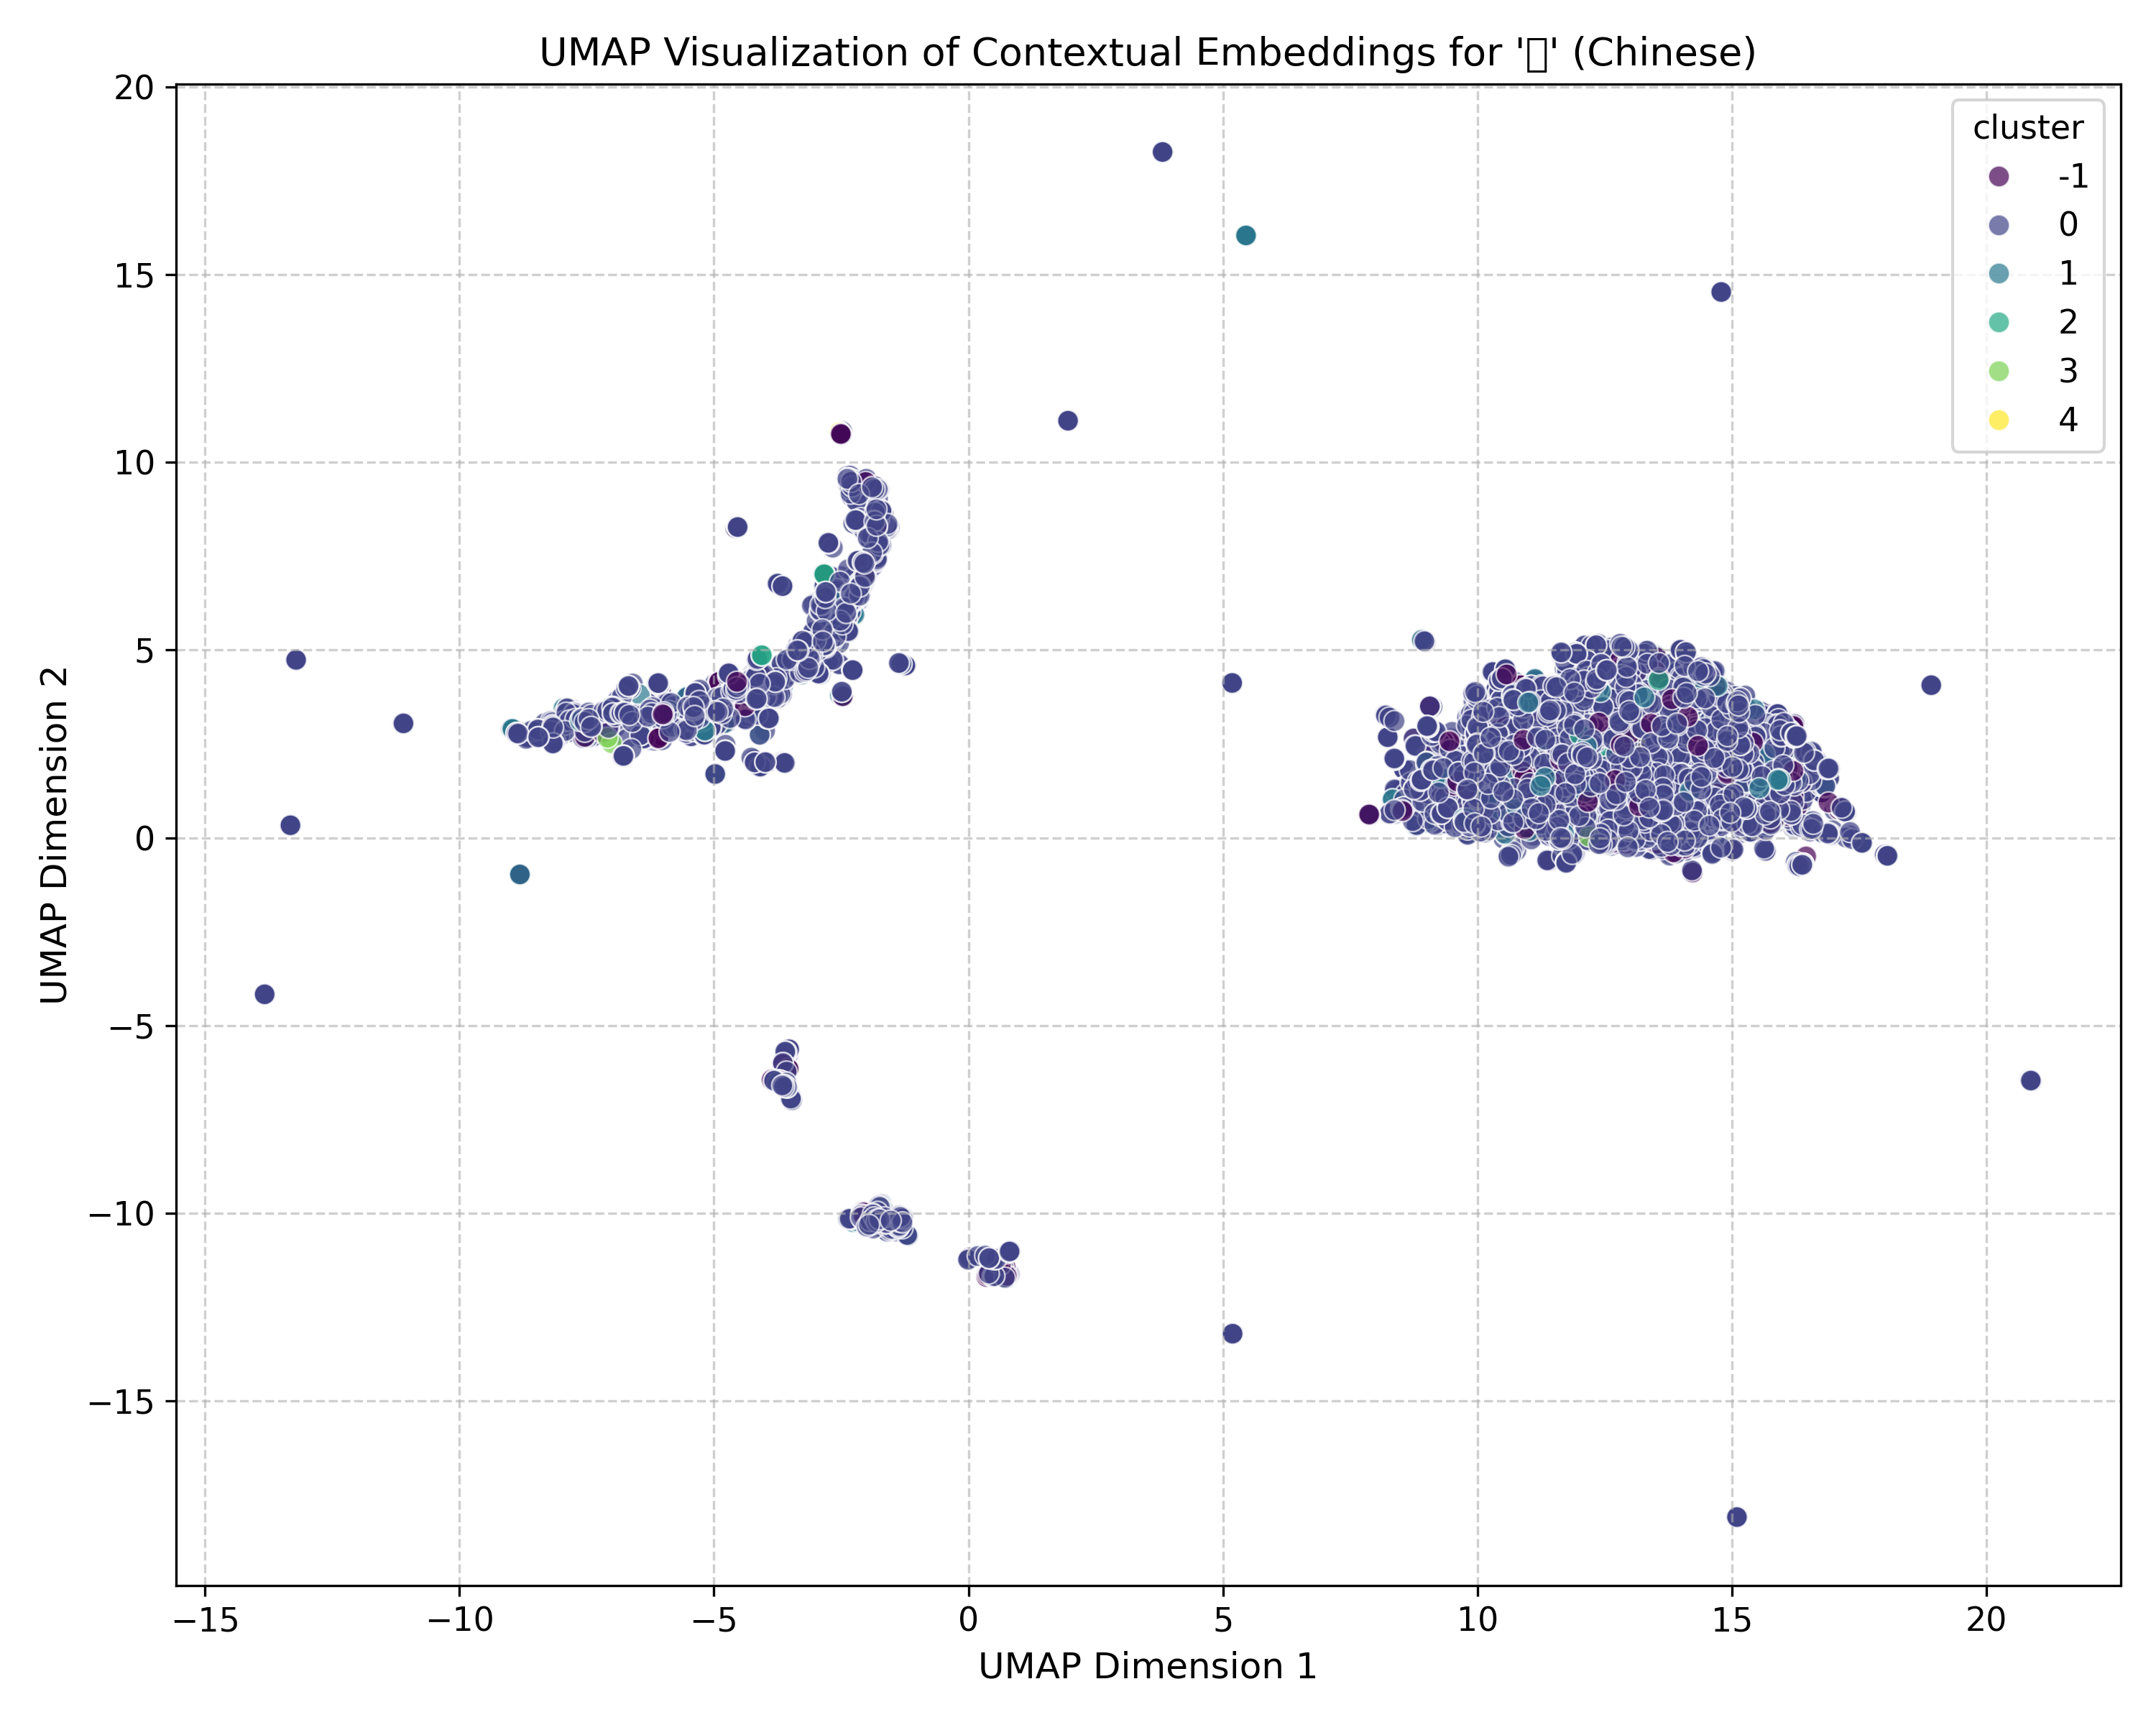

In [33]:
from IPython.display import Image, display
from pathlib import Path

# Assuming OUTPUT_DIR is defined and the filename convention
OUTPUT_DIR = Path("/content") / "output"
lemma_to_analyze = '人'
plot_filename = OUTPUT_DIR / "figures" / f"umap_clusters_{lemma_to_analyze}_chinese.png"

if plot_filename.exists():
    print(f"Displaying: {plot_filename}")
    display(Image(filename=plot_filename))
else:
    print(f"Plot file not found at {plot_filename}")

In [40]:
print(zho_sense_labels['cluster_hdbscan'].unique())

[ 0 -1  1  2  3  4]


In [34]:
import pandas as pd

# Load WSI results
df_zh = pd.read_csv("bible_data/chinese_wsi_results.csv")

# Sort by polysemy to inspect high-k words
high_k = df_zh[df_zh['k_hdbscan'] >= 2].sort_values('k_hdbscan', ascending=False)

print(f"Found {len(high_k)} polysemous words")
print("\nTop 30 polysemous words to inspect:")
print(high_k[['lemma', 'n_instances', 'k_hdbscan']].head(30))

# Check for suspicious patterns
suspicious = []

for idx, row in high_k.iterrows():
    lemma = row['lemma']
    flags = []

    # Flag 1: Contains common verb characters
    verb_chars = '說來去作使見知行得成為給立取求呼問答聽';
    if any(c in lemma for c in verb_chars):
        flags.append("VERB_CHAR")

    # Flag 2: Starts with 主 (Lord) - might be "Lord + verb"
    if lemma.startswith('主') and len(lemma) > 1:
        flags.append("主+X")

    # Flag 3: Starts with common proper name prefixes
    proper_prefixes = '亞以所耶撒利摩迦法馬雅巴該西拉';
    if lemma[0] in proper_prefixes and len(lemma) == 2:
        flags.append("PROPER_FRAGMENT?")

    # Flag 4: Very short (2 chars) with high k - suspicious
    if len(lemma) == 2 and row['k_hdbscan'] >= 3:
        flags.append("SHORT+HIGH_K")

    if flags:
        suspicious.append({
            'lemma': lemma,
            'n': row['n_instances'],
            'k': row['k_hdbscan'],
            'flags': ', '.join(flags)
        })

df_suspicious = pd.DataFrame(suspicious)
print(f"\n{len(df_suspicious)} suspicious lemmas flagged:")
print(df_suspicious.to_string(index=False))

# Save for manual review
df_suspicious.to_csv("bible_data/suspicious_lemmas_to_review.csv", index=False)
print("\nSaved to: suspicious_lemmas_to_review.csv")

Found 96 polysemous words

Top 30 polysemous words to inspect:
    lemma  n_instances  k_hdbscan
131    子孫          429          5
441    郊野          117          5
388   舍客勒          128          5
319     祭          112          4
134    孩子          203          3
24     供物           98          3
104     壇          267          3
128    婦人          314          3
206     時          166          3
481    首領          276          3
398     處          209          3
378    脂油           91          3
42      公           56          2
1      下體           41          2
10      人         9247          2
8      主人          182          2
63      口           69          2
61    十字架           83          2
52     凡事           79          2
49     兵器           75          2
93      城          692          2
75      嘴           77          2
85      地         1396          2
77     器具           64          2
111    天使          173          2
43     公平           88          2
45     公羊          